# ETF 20-Day Relative-Performance Labels & Model (Colab)

Trains an XGBoost model (tuned with Optuna, 60 trials) to predict whether a fund will **Outperform**, be **Neutral**, or **Underperform** its category peers over the next 20 trading days, for a curated universe of ~188 ETFs across 35 category groups (sector, style-box, international, bond, commodity, factor, thematic).

Loads a pre-built dataset (`etf_labeled_5y_ta_features.csv`) rather than re-pulling from yfinance on every run — the pull, feature engineering, and label construction already happened once (5y daily OHLCV via `yfinance` with `auto_adjust=True`, so Open/High/Low/Close are split/dividend-adjusted; 5 causal features; labels from the 20-day forward relative return). 6 pandas-ta technical indicators (RSI, StochRSI, Bollinger %B, CCI, PGO, Fisher transform) were computed on top of that, each per-fund and then cross-sectionally z-scored within `(date, category)` groups. The result (12 features total) is saved in `data/processed/`. The markdown cells below document that construction for reference even though the code that recomputes it has been replaced with a load step.

Works two ways, tried in this order:
1. **Google Colab** — upload `etf_labeled_5y_ta_features.csv` (~150MB) into `/content/Funds/` (or straight into `/content/`). If the plain CSV is too slow/unreliable to upload through your extension's widget, upload the smaller gzip-compressed `etf_labeled_5y_ta_features.csv.gz` (~62MB) instead — the loader checks for either.
2. **Local / this repo** — falls back to this repo's own `data/processed/` folder (works as long as this notebook stays inside `notebooks/`, e.g. running it locally in an IDE against this project's `venv`).

In [2]:
import os
import pandas as pd
import numpy as np

COLAB_DIR = '/content/Funds'
LOCAL_PROC = os.path.join('..', 'data', 'processed')

if os.path.isdir('/content'):
    os.makedirs(COLAB_DIR, exist_ok=True)

def resolve_path(filename, local_dir):
    # tries the plain filename first (what's used locally), then a gzip-compressed
    # variant (filename + '.gz') - useful on Colab where uploading the smaller .gz
    # file is far more reliable than the full-size .csv through some upload widgets.
    # pandas.read_csv auto-detects gzip compression from the .gz extension.
    names = [filename, filename + '.gz']
    candidates = []
    for name in names:
        candidates += [f'{COLAB_DIR}/{name}', f'/content/{name}', os.path.join(local_dir, name)]
    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(
        f"Couldn't find {filename} (checked both plain and .gz). Tried: {candidates}. On Colab: "
        f"upload either the plain .csv or the smaller .csv.gz to /content/Funds/ (or /content/ "
        f"directly). Running locally: make sure this notebook is still inside the repo's "
        f"notebooks/ folder, so the ../data/processed fallback can find it."
    )

data_path = resolve_path('etf_labeled_5y_ta_features.csv', LOCAL_PROC)
etf_data = pd.read_csv(data_path, parse_dates=['date'])
etf_data = etf_data.sort_values(['fund_id', 'date']).reset_index(drop=True)

print('Loaded:', data_path)
print('Rows:', len(etf_data))
print('Date range:', etf_data['date'].min(), 'to', etf_data['date'].max())
print('Unique funds:', etf_data['fund_id'].nunique())
print('Unique categories:', etf_data['category'].nunique())

Loaded: /content/etf_labeled_5y_ta_features.csv.gz
Rows: 234498
Date range: 2021-07-15 00:00:00 to 2026-07-14 00:00:00
Unique funds: 187
Unique categories: 35


## Feature engineering (already computed)

All 5 original features are constructed causally (backward-looking only) and are already present as columns in the loaded dataset — shown below for reference, not recomputed. The dataset also includes 6 additional pandas-ta technical indicators (RSI(3), StochRSI, Bollinger %B(20), CCI(20), PGO(14), Fisher transform), each computed per-fund and then cross-sectionally z-scored within `(date, category)` groups (the `*_z` columns) — same idea as `peer_rank_20d`, just added afterward on top of the original 5.

### beta_60d (vectorized)

Rolling 60-day beta vs. an equal-weighted, self-excluded category benchmark, computed via rolling-sum covariance/variance algebra instead of `groupby().apply()` - required to keep this fast at >200k rows. Already present in the loaded dataset (see the `beta_60d` column) - shown here for reference, not recomputed.

In [3]:
feature_cols = [
    "peer_rank_20d", "ret_5d", "ret_20d_skip5", "vol_20d", "beta_60d",
    "RSI_3_z", "STOCHRSIk_14_14_3_3_z", "STOCHRSId_14_14_3_3_z",
    "BBP_20_2.0_2.0_z", "CCI_20_0.015_z", "PGO_14_z", "FISHERT_9_1_z",
]
print("NaN counts per feature (expected: warm-up window rows per fund):")
print(etf_data[feature_cols].isna().sum())
print()
print("Rows with all", len(feature_cols), "features populated:", etf_data[feature_cols].notna().all(axis=1).sum(), "of", len(etf_data))

NaN counts per feature (expected: warm-up window rows per fund):
peer_rank_20d             3740
ret_5d                     935
ret_20d_skip5             4675
vol_20d                   3740
beta_60d                 11220
RSI_3_z                    196
STOCHRSIk_14_14_3_3_z     3001
STOCHRSId_14_14_3_3_z     3375
BBP_20_2.0_2.0_z          3712
CCI_20_0.015_z            3712
PGO_14_z                  2590
FISHERT_9_1_z             1655
dtype: int64

Rows with all 12 features populated: 223119 of 234498


## Label construction (already computed)

`fwd_relative_return` = fund's forward 20-day return minus the equal-weighted average forward 20-day return of all other funds in the same category (self-excluded). Labels use the 15th/85th percentile of this distribution as boundaries, chosen to give an exact 15% Underperform / 70% Neutral / 15% Outperform split. Both `fwd_relative_return` and `label` are already columns in the loaded dataset; the cell below just re-derives the threshold values (`lower_q`/`upper_q`) needed later for the diagnostic section, and reprints the same summary as when this dataset was built.

In [4]:
valid_fwd = etf_data["fwd_relative_return"].dropna()
lower_q = valid_fwd.quantile(0.15)
upper_q = valid_fwd.quantile(0.85)
print("Underperform cutoff (15th pct):", round(lower_q * 10000, 2), "bps (", round(lower_q * 100, 3), "%)")
print("Outperform cutoff (85th pct):", round(upper_q * 10000, 2), "bps (", round(upper_q * 100, 3), "%)")

labeled = etf_data["label"].dropna()
print()
print("Labeled rows:", len(labeled), "of", len(etf_data))
print(labeled.value_counts())
print()
print((labeled.value_counts(normalize=True) * 100).round(2))

Underperform cutoff (15th pct): -60.63 bps ( -0.606 %)
Outperform cutoff (85th pct): 59.7 bps ( 0.597 %)

Labeled rows: 233390 of 234498
label
Neutral         163372
Underperform     35009
Outperform       35009
Name: count, dtype: int64

label
Neutral         70.0
Underperform    15.0
Outperform      15.0
Name: proportion, dtype: float64


## Modeling: XGBoost with Optuna hyperparameter tuning (60 trials)

Time-based 70/15/15 train/val/test split with a 20-trading-day embargo gap after each boundary (labels depend on prices through t+20, so a gap prevents any label window from straddling a split).

In [5]:
!pip install -q optuna xgboost
import xgboost as xgb
import optuna
print("xgboost", xgb.__version__)
print("optuna", optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.9 MB/s eta 0:00:00
xgboost 3.3.0
optuna 4.9.0


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

feature_cols = [
    "peer_rank_20d", "ret_5d", "ret_20d_skip5", "vol_20d", "beta_60d",
    "RSI_3_z", "STOCHRSIk_14_14_3_3_z", "STOCHRSId_14_14_3_3_z",
    "BBP_20_2.0_2.0_z", "CCI_20_0.015_z", "PGO_14_z", "FISHERT_9_1_z",
]
label_map = {"Underperform": 0, "Neutral": 1, "Outperform": 2}
inv_label_map = {v: k for k, v in label_map.items()}

model_df = etf_data.dropna(subset=feature_cols + ["label"]).copy()
model_df["label_enc"] = model_df["label"].map(label_map)

print("Modeling rows:", len(model_df), "of", len(etf_data))
print(model_df["label"].value_counts())
print("Date range:", model_df["date"].min(), "to", model_df["date"].max())

Modeling rows: 222170 of 234498
label
Neutral         155068
Underperform     33554
Outperform       33548
Name: count, dtype: int64
Date range: 2021-10-08 00:00:00 to 2026-07-07 00:00:00


In [7]:
EMBARGO_DAYS = 20
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

unique_dates = np.sort(model_df["date"].unique())
n_dates = len(unique_dates)

train_end_i = int(n_dates * TRAIN_FRAC)
val_end_i = int(n_dates * (TRAIN_FRAC + VAL_FRAC))

train_dates = unique_dates[:train_end_i]
val_dates = unique_dates[train_end_i + EMBARGO_DAYS: val_end_i]
test_dates = unique_dates[val_end_i + EMBARGO_DAYS:]

train_df = model_df[model_df["date"].isin(train_dates)]
val_df = model_df[model_df["date"].isin(val_dates)]
test_df = model_df[model_df["date"].isin(test_dates)]

print("Train:", pd.Timestamp(train_dates.min()).date(), "to", pd.Timestamp(train_dates.max()).date(), "-", len(train_df), "rows")
print("Val:  ", pd.Timestamp(val_dates.min()).date(), "to", pd.Timestamp(val_dates.max()).date(), "-", len(val_df), "rows")
print("Test: ", pd.Timestamp(test_dates.min()).date(), "to", pd.Timestamp(test_dates.max()).date(), "-", len(test_df), "rows")
print("Embargo gap:", EMBARGO_DAYS, "trading days after each split boundary")

X_train = train_df[feature_cols].values
y_train = train_df["label_enc"].values
X_val = val_df[feature_cols].values
y_val = val_df["label_enc"].values
X_test = test_df[feature_cols].values
y_test = test_df["label_enc"].values

print()
print("Class distribution (train):")
print(train_df["label"].value_counts(normalize=True).round(3))
print()
print("Class distribution (val):")
print(val_df["label"].value_counts(normalize=True).round(3))
print()
print("Class distribution (test):")
print(test_df["label"].value_counts(normalize=True).round(3))

Train: 2021-10-08 to 2025-01-31 - 155584 rows
Val:   2025-03-04 to 2025-10-16 - 29546 rows
Test:  2025-11-14 to 2026-07-07 - 29560 rows
Embargo gap: 20 trading days after each split boundary

Class distribution (train):
label
Neutral         0.703
Outperform      0.150
Underperform    0.147
Name: proportion, dtype: float64

Class distribution (val):
label
Neutral         0.717
Underperform    0.146
Outperform      0.137
Name: proportion, dtype: float64

Class distribution (test):
label
Neutral         0.652
Underperform    0.178
Outperform      0.170
Name: proportion, dtype: float64


In [8]:
sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sw_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average="macro")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print("Best validation macro F1:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(" ", k, "=", v)

  0%|          | 0/60 [00:00<?, ?it/s]

Best validation macro F1: 0.49154858710172916
Best params:
  max_depth = 7
  learning_rate = 0.1336433731660479
  n_estimators = 498
  subsample = 0.9179707006207019
  colsample_bytree = 0.7646949393948328
  min_child_weight = 8
  reg_alpha = 2.892560362988924
  reg_lambda = 0.008818520122169559


XGBoost model - test set performance
              precision    recall  f1-score   support

Underperform      0.323     0.386     0.352      5260
     Neutral      0.859     0.777     0.816     19274
  Outperform      0.328     0.380     0.352      5026

    accuracy                          0.640     29560
   macro avg      0.503     0.515     0.507     29560
weighted avg      0.673     0.640     0.655     29560



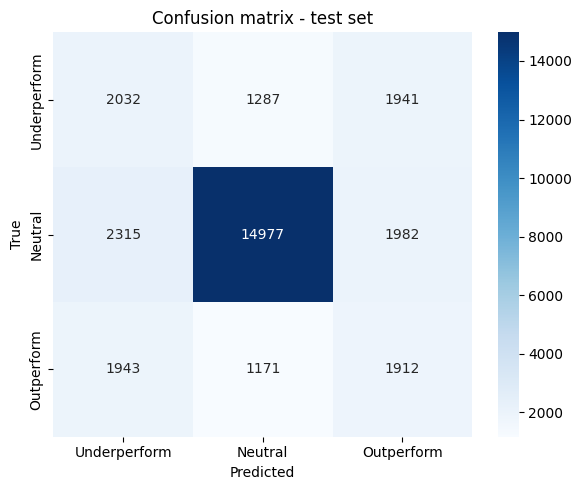


Baseline: always predict Neutral
 accuracy: 0.652  macro F1: 0.2631

Baseline: predict category's most common training-period label
 accuracy: 0.675  macro F1: 0.3996

XGBoost model
 accuracy: 0.6401  macro F1: 0.5066


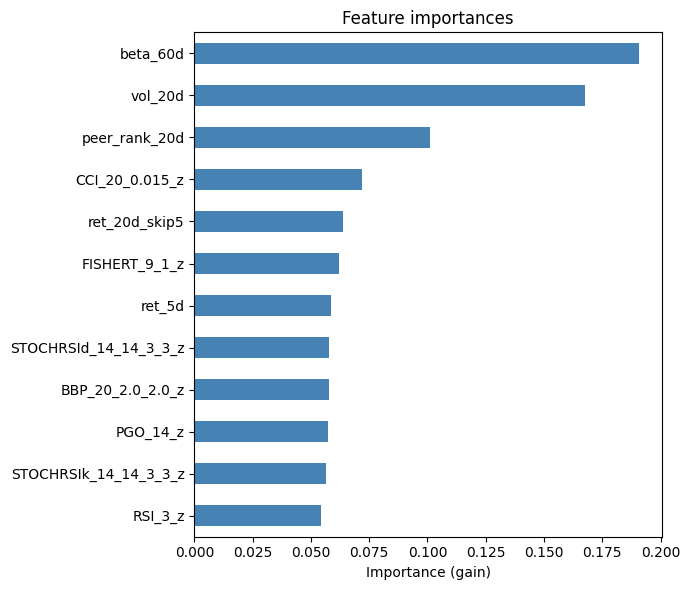

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

best_params = dict(study.best_params)
best_params.update({
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
})

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
sw_trainval = compute_sample_weight(class_weight="balanced", y=y_trainval)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval)

test_preds = final_model.predict(X_test)
target_names = ["Underperform", "Neutral", "Outperform"]

print("XGBoost model - test set performance")
print(classification_report(y_test, test_preds, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix - test set")
plt.tight_layout()
plt.show()

baseline_neutral = np.full_like(y_test, fill_value=label_map["Neutral"])
cat_mode = train_df.groupby("category")["label"].agg(lambda s: s.value_counts().idxmax())
baseline_cat = test_df["category"].map(cat_mode).map(label_map).fillna(label_map["Neutral"]).astype(int).values

print()
print("Baseline: always predict Neutral")
print(" accuracy:", round((baseline_neutral == y_test).mean(), 4), " macro F1:", round(f1_score(y_test, baseline_neutral, average="macro"), 4))

print()
print("Baseline: predict category's most common training-period label")
print(" accuracy:", round((baseline_cat == y_test).mean(), 4), " macro F1:", round(f1_score(y_test, baseline_cat, average="macro"), 4))

print()
print("XGBoost model")
print(" accuracy:", round((test_preds == y_test).mean(), 4), " macro F1:", round(f1_score(y_test, test_preds, average="macro"), 4))

feat_importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 6))
feat_importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("Feature importances")
plt.tight_layout()
plt.show()

## Diagnostic: are Under/Outperform mix-ups boundary noise or genuine direction errors?

Checks whether rows where the true label is Underperform but the model predicted Outperform (and vice versa) sit near the label boundary or deep in the tail of `fwd_relative_return`. Evaluates the hypothesis that the +/-0.6% boundaries are too close together and that this alone explains the confusion-matrix mix-ups.

In [10]:
test_eval = test_df.copy()
test_eval["pred_label"] = pd.Series(test_preds, index=test_eval.index).map(inv_label_map)

flip_u2o = test_eval[(test_eval["label"] == "Underperform") & (test_eval["pred_label"] == "Outperform")]
flip_o2u = test_eval[(test_eval["label"] == "Outperform") & (test_eval["pred_label"] == "Underperform")]
correct_under = test_eval[(test_eval["label"] == "Underperform") & (test_eval["pred_label"] == "Underperform")]
correct_over = test_eval[(test_eval["label"] == "Outperform") & (test_eval["pred_label"] == "Outperform")]

print("Underperform boundary (15th pct):", round(lower_q * 100, 3), "%")
print("Outperform boundary (85th pct):", round(upper_q * 100, 3), "%")

p05 = valid_fwd.quantile(0.05)
p95 = valid_fwd.quantile(0.95)
print("5th pct (deep underperform tail):", round(p05 * 100, 3), "%")
print("95th pct (deep outperform tail):", round(p95 * 100, 3), "%")
print()

print("True Underperform -> Predicted Outperform:", len(flip_u2o), "rows")
print(" deep in tail (more extreme than 5th pct):", (flip_u2o["fwd_relative_return"] < p05).sum(), "of", len(flip_u2o))
print(" near boundary (between 15th and 5th pct):", ((flip_u2o["fwd_relative_return"] >= p05) & (flip_u2o["fwd_relative_return"] < lower_q)).sum(), "of", len(flip_u2o))
print()

print("True Outperform -> Predicted Underperform:", len(flip_o2u), "rows")
print(" deep in tail (more extreme than 95th pct):", (flip_o2u["fwd_relative_return"] > p95).sum(), "of", len(flip_o2u))
print(" near boundary (between 85th and 95th pct):", ((flip_o2u["fwd_relative_return"] <= p95) & (flip_o2u["fwd_relative_return"] > upper_q)).sum(), "of", len(flip_o2u))
print()

print("Median fwd_relative_return:")
print(" correct Underperform:", round(correct_under["fwd_relative_return"].median() * 100, 3), "% vs flipped-to-Outperform:", round(flip_u2o["fwd_relative_return"].median() * 100, 3), "%")
print(" correct Outperform:  ", round(correct_over["fwd_relative_return"].median() * 100, 3), "% vs flipped-to-Underperform:", round(flip_o2u["fwd_relative_return"].median() * 100, 3), "%")

Underperform boundary (15th pct): -0.606 %
Outperform boundary (85th pct): 0.597 %
5th pct (deep underperform tail): -1.699 %
95th pct (deep outperform tail): 1.665 %

True Underperform -> Predicted Outperform: 1941 rows
 deep in tail (more extreme than 5th pct): 872 of 1941
 near boundary (between 15th and 5th pct): 1069 of 1941

True Outperform -> Predicted Underperform: 1943 rows
 deep in tail (more extreme than 95th pct): 920 of 1943
 near boundary (between 85th and 95th pct): 1023 of 1943

Median fwd_relative_return:
 correct Underperform: -1.505 % vs flipped-to-Outperform: -1.563 %
 correct Outperform:   1.687 % vs flipped-to-Underperform: 1.561 %


## ROC AUC: Outperform vs. rest

One-vs-rest ROC curve and AUC for the `Outperform` class (vs. `Neutral`/`Underperform` combined), using the final model's predicted probabilities on the held-out test set.

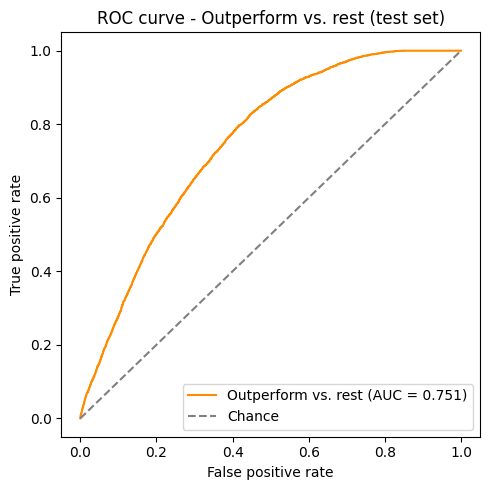

Outperform vs. rest ROC AUC: 0.7506


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

outperform_idx = label_map["Outperform"]
y_test_outperform = (y_test == outperform_idx).astype(int)
test_probs_outperform = final_model.predict_proba(X_test)[:, outperform_idx]

outperform_auc = roc_auc_score(y_test_outperform, test_probs_outperform)
fpr, tpr, _ = roc_curve(y_test_outperform, test_probs_outperform)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="darkorange", label=f"Outperform vs. rest (AUC = {outperform_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve - Outperform vs. rest (test set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Outperform vs. rest ROC AUC:", round(outperform_auc, 4))

In [12]:
final_model.save_model("20_Days_classifier.json")